<a href="https://colab.research.google.com/github/alaae2007/CST184/blob/main/Week_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nodes Dataset:
    name         type  gender region
0  Aisha      Student  Female  North
1    Ben      Student    Male  South
2  Chloe      Teacher  Female  North
3  David      Student    Male   East
4  Elena       Mentor  Female   West
5  Farid      Student    Male  South
6  Grace      Student  Female   East
7   Hugo  Coordinator    Male  North

Edges Dataset:
  Source Target  Weight
0  Aisha  Chloe       5
1    Ben  Farid       3
2  Chloe  David       4
3  David  Elena       2
4  Elena  Grace       4
5  Grace  Farid       3
6   Hugo  Chloe       4
7   Hugo  Elena       2
8  Aisha    Ben       2
9  Grace    Ben       3

Graph created successfully.

Number of nodes: 8
Number of edges: 10
Is the network connected? True

Node Degrees:
Aisha: Degree = 2
Ben: Degree = 3
Chloe: Degree = 3
David: Degree = 2
Elena: Degree = 3
Farid: Degree = 2
Grace: Degree = 3
Hugo: Degree = 2

Most connected people:
['Ben', 'Chloe', 'Elena', 'Grace']

Highest degree:
3

People with only one connection:
[]



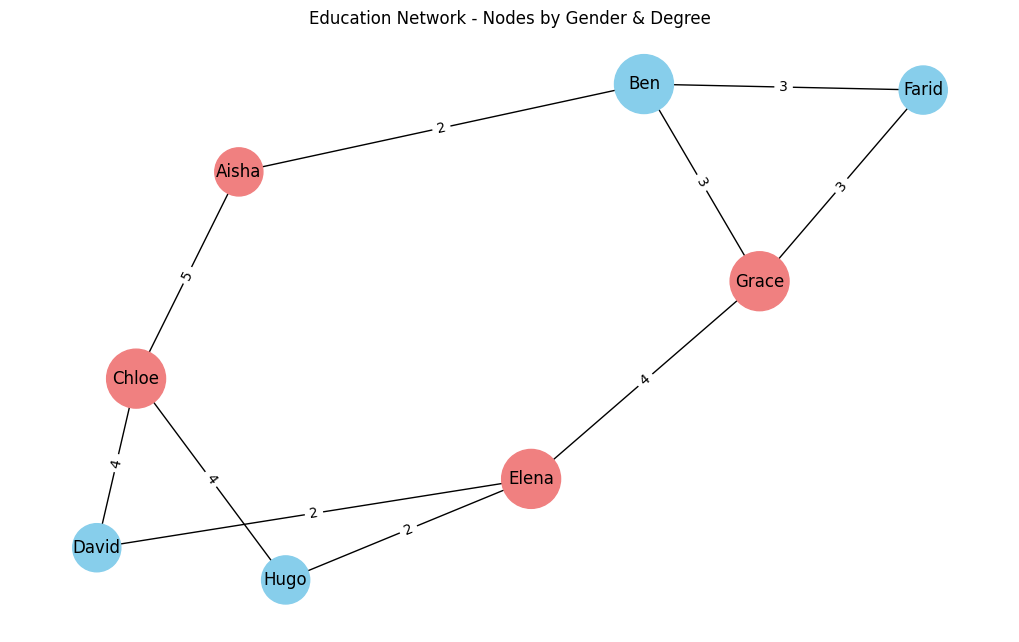


Step 4 Answer:

The network visualisation shows that all eight people are part of one
connected network.

Larger nodes represent people with more direct connections. Ben,
Chloe, Elena and Grace therefore appear larger because they each have
three connections.

Elena is especially important because the centrality analysis shows
that she frequently lies on paths connecting different parts of the
network.

There are no completely isolated people in the original network.

However, people with fewer connections may be more vulnerable to
exclusion if one of their existing relationships is removed.


After removing the connection between Ben and Farid:
Is the network connected? True

Updated degrees:
Aisha: Degree = 2
Ben: Degree = 2
Chloe: Degree = 3
David: Degree = 2
Elena: Degree = 3
Farid: Degree = 1
Grace: Degree = 3
Hugo: Degree = 2


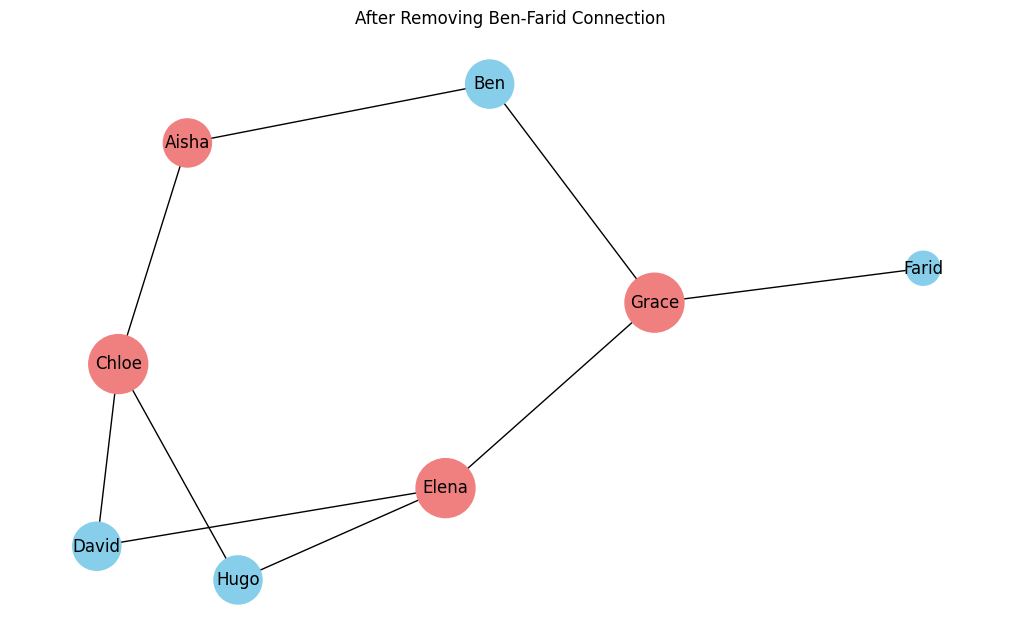


Network Change Analysis:

After removing the connection between Ben and Farid, the network is
still connected.

However, Farid now has only one direct connection, which is Grace.

This makes Farid more vulnerable to isolation. If the connection
between Grace and Farid was also removed, Farid would become
completely disconnected from the network.

This demonstrates how removing even one relationship can increase the
risk of exclusion for less-connected members.


New mentor Maya added.
Number of nodes: 9
Number of edges: 11
Is the network connected? True


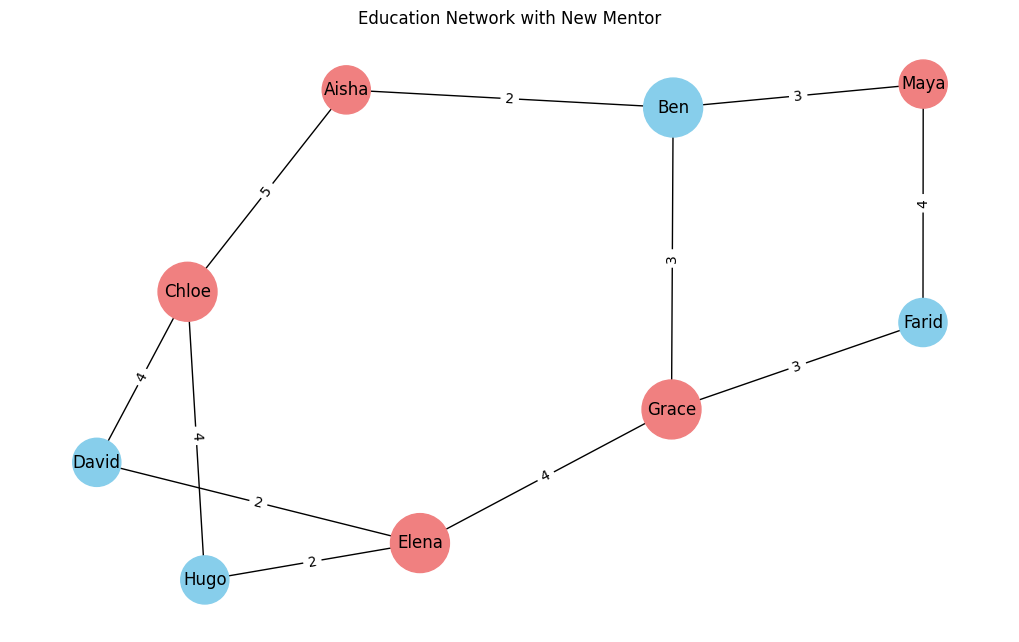


New Mentor Analysis:

Adding Maya as a mentor creates additional connections for Farid and
Ben.

This improves Farid's position in the network because Farid is no
longer dependent on only one direct connection.

In a real education network, adding mentors or creating new
collaborative relationships could help reduce the risk of students
becoming isolated.



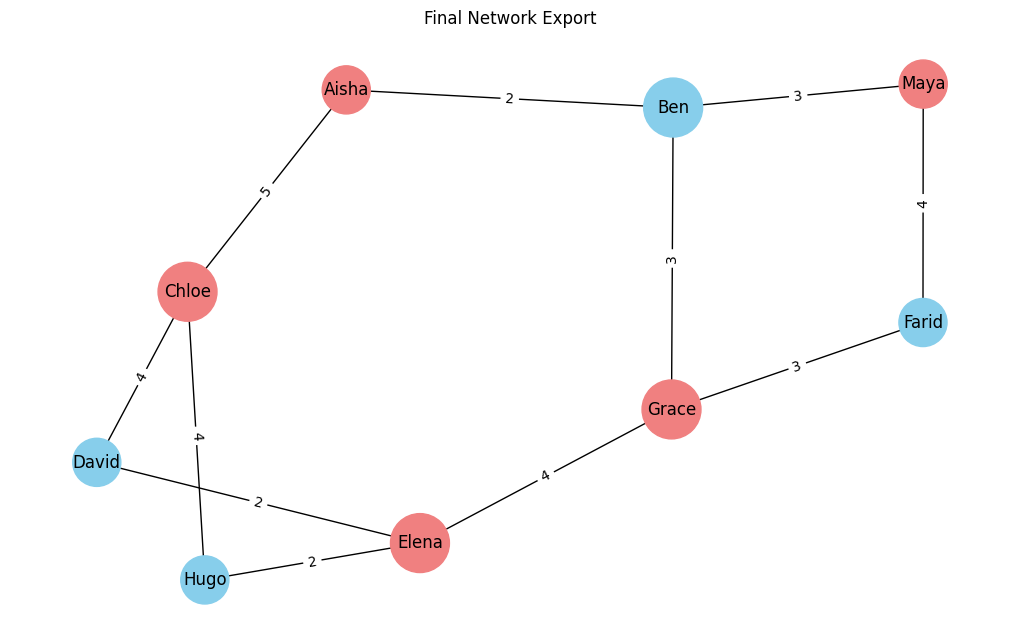


Final network image saved as week5_network_final.png

Summary and Reflection:

1. Who plays a central role in the network?

Elena has the highest betweenness centrality, making her an important
connector between different parts of the network.

Grace also has a high centrality score and plays an important
connecting role.

Ben, Chloe, Elena and Grace have the highest number of direct
connections, with a degree of 3 each.


2. Which nodes may be isolated or at risk of exclusion?

There are no isolated nodes in the original network.

However, after removing the Ben-Farid connection, Farid has only one
remaining direct connection. This places Farid at greater risk of
becoming isolated.


3. Where could connectivity be improved?

Additional relationships could be created for people with fewer
connections.

Adding the new mentor Maya and connecting her to Farid provides Farid
with another pathway into the network and reduces the risk of
exclusion.


4. What does centrality tell us?

Betwee

In [1]:
# CST184 Week 5
# Graph Theory & Network Visualization
# Mapping Learning Networks

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


# Step 1: Load the datasets

nodes_df = pd.read_csv("week5_tutorial_nodes.csv")
edges_df = pd.read_csv("week5_tutorial_edges.csv")

print("Nodes Dataset:")
print(nodes_df)

print("\nEdges Dataset:")
print(edges_df)


# Create the graph

G = nx.Graph()

for _, row in nodes_df.iterrows():
    G.add_node(
        row["name"],
        type=row["type"],
        gender=row["gender"],
        region=row["region"]
    )

for _, row in edges_df.iterrows():
    G.add_edge(
        row["Source"],
        row["Target"],
        weight=row["Weight"]
    )

print("\nGraph created successfully.")


# Step 2: Analyse the graph structure

print("\nNumber of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is the network connected?", nx.is_connected(G))

print("\nNode Degrees:")

for node in G.nodes():
    print(f"{node}: Degree = {G.degree(node)}")


# Find the most connected people

degrees = dict(G.degree())

highest_degree = max(degrees.values())

most_connected = [
    node
    for node, degree in degrees.items()
    if degree == highest_degree
]

one_connection = [
    node
    for node, degree in degrees.items()
    if degree == 1
]

print("\nMost connected people:")
print(most_connected)

print("\nHighest degree:")
print(highest_degree)

print("\nPeople with only one connection:")
print(one_connection)


# Step 2 Prompt

print("\nStep 2 Answer:")

print("""
Ben, Chloe, Elena and Grace are the most connected people in the
network. Each has a degree of 3, meaning they each have three direct
connections.

Initially, nobody has only one connection. Aisha, David, Farid and
Hugo each have two connections.

The network is connected, meaning every person can reach every other
person either directly or indirectly.
""")


# Step 3: Betweenness centrality

centrality = nx.betweenness_centrality(G)

print("\nBetweenness Centrality:")

for person, value in centrality.items():
    print(f"{person}: {round(value, 3)}")


# Find person with highest centrality

highest_centrality_person = max(
    centrality,
    key=centrality.get
)

print(
    "\nHighest betweenness centrality:",
    highest_centrality_person
)

print(
    "Centrality score:",
    round(centrality[highest_centrality_person], 3)
)


# Clustering coefficient

clustering = nx.clustering(G)

print("\nClustering Coefficient:")

for person, value in clustering.items():
    print(f"{person}: {round(value, 2)}")


# Step 3 Prompt

print("\nStep 3 Answer:")

print("""
Elena has the highest betweenness centrality in the network at
approximately 0.294.

This suggests Elena plays an important role in connecting different
parts of the learning network.

Grace also has relatively high betweenness centrality at approximately
0.254, followed by Chloe and Ben.

Farid has a clustering coefficient of 1.0. This means Farid's
neighbours are also directly connected to each other.

Ben and Grace both have clustering coefficients of approximately
0.33, showing some local clustering around these people.

The remaining nodes have clustering coefficients of 0, meaning their
neighbours are not directly connected to each other.
""")


# Step 4: Visualise the network

pos = nx.spring_layout(G, seed=42)

gender_colors = {
    "Male": "skyblue",
    "Female": "lightcoral"
}

node_colors = [
    gender_colors[G.nodes[node]["gender"]]
    for node in G.nodes()
]

node_sizes = [
    G.degree(node) * 600
    for node in G.nodes()
]

plt.figure(figsize=(10, 6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=node_sizes
)

edge_labels = nx.get_edge_attributes(
    G,
    "weight"
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title("Education Network - Nodes by Gender & Degree")
plt.show()


# Step 4 Prompt

print("\nStep 4 Answer:")

print("""
The network visualisation shows that all eight people are part of one
connected network.

Larger nodes represent people with more direct connections. Ben,
Chloe, Elena and Grace therefore appear larger because they each have
three connections.

Elena is especially important because the centrality analysis shows
that she frequently lies on paths connecting different parts of the
network.

There are no completely isolated people in the original network.

However, people with fewer connections may be more vulnerable to
exclusion if one of their existing relationships is removed.
""")


# Step 5: Modify the network

G_modified = G.copy()

G_modified.remove_edge(
    "Ben",
    "Farid"
)

print("\nAfter removing the connection between Ben and Farid:")
print(
    "Is the network connected?",
    nx.is_connected(G_modified)
)

print("\nUpdated degrees:")

for node in G_modified.nodes():
    print(
        f"{node}: Degree = {G_modified.degree(node)}"
    )


# Create a new layout for the modified network

pos_modified = nx.spring_layout(
    G_modified,
    seed=42
)

modified_colors = [
    gender_colors[G_modified.nodes[node]["gender"]]
    for node in G_modified.nodes()
]

modified_sizes = [
    G_modified.degree(node) * 600
    for node in G_modified.nodes()
]

plt.figure(figsize=(10, 6))

nx.draw(
    G_modified,
    pos_modified,
    with_labels=True,
    node_color=modified_colors,
    node_size=modified_sizes
)

plt.title("After Removing Ben-Farid Connection")
plt.show()


# Explain what changed

print("\nNetwork Change Analysis:")

print("""
After removing the connection between Ben and Farid, the network is
still connected.

However, Farid now has only one direct connection, which is Grace.

This makes Farid more vulnerable to isolation. If the connection
between Grace and Farid was also removed, Farid would become
completely disconnected from the network.

This demonstrates how removing even one relationship can increase the
risk of exclusion for less-connected members.
""")


# Try This: Add a new mentor

G_modified.add_node(
    "Maya",
    type="Mentor",
    gender="Female",
    region="South"
)

G_modified.add_edge(
    "Maya",
    "Farid",
    weight=4
)

G_modified.add_edge(
    "Maya",
    "Ben",
    weight=3
)

print("\nNew mentor Maya added.")

print(
    "Number of nodes:",
    G_modified.number_of_nodes()
)

print(
    "Number of edges:",
    G_modified.number_of_edges()
)

print(
    "Is the network connected?",
    nx.is_connected(G_modified)
)


# Visualise the network with the new mentor

pos_final = nx.spring_layout(
    G_modified,
    seed=42
)

final_colors = [
    gender_colors[G_modified.nodes[node]["gender"]]
    for node in G_modified.nodes()
]

final_sizes = [
    G_modified.degree(node) * 600
    for node in G_modified.nodes()
]

plt.figure(figsize=(10, 6))

nx.draw(
    G_modified,
    pos_final,
    with_labels=True,
    node_color=final_colors,
    node_size=final_sizes
)

final_edge_labels = nx.get_edge_attributes(
    G_modified,
    "weight"
)

nx.draw_networkx_edge_labels(
    G_modified,
    pos_final,
    edge_labels=final_edge_labels
)

plt.title("Education Network with New Mentor")
plt.show()


# Explain the new mentor

print("\nNew Mentor Analysis:")

print("""
Adding Maya as a mentor creates additional connections for Farid and
Ben.

This improves Farid's position in the network because Farid is no
longer dependent on only one direct connection.

In a real education network, adding mentors or creating new
collaborative relationships could help reduce the risk of students
becoming isolated.
""")


# Step 6: Save the final graph as an image

plt.figure(figsize=(10, 6))

nx.draw(
    G_modified,
    pos_final,
    with_labels=True,
    node_color=final_colors,
    node_size=final_sizes
)

nx.draw_networkx_edge_labels(
    G_modified,
    pos_final,
    edge_labels=final_edge_labels
)

plt.title("Final Network Export")

plt.savefig(
    "week5_network_final.png",
    bbox_inches="tight"
)

plt.show()

print(
    "\nFinal network image saved as "
    "week5_network_final.png"
)


# Summary and Reflection

print("\nSummary and Reflection:")

print("""
1. Who plays a central role in the network?

Elena has the highest betweenness centrality, making her an important
connector between different parts of the network.

Grace also has a high centrality score and plays an important
connecting role.

Ben, Chloe, Elena and Grace have the highest number of direct
connections, with a degree of 3 each.


2. Which nodes may be isolated or at risk of exclusion?

There are no isolated nodes in the original network.

However, after removing the Ben-Farid connection, Farid has only one
remaining direct connection. This places Farid at greater risk of
becoming isolated.


3. Where could connectivity be improved?

Additional relationships could be created for people with fewer
connections.

Adding the new mentor Maya and connecting her to Farid provides Farid
with another pathway into the network and reduces the risk of
exclusion.


4. What does centrality tell us?

Betweenness centrality helps identify people who act as bridges
between different parts of a network.

Elena's high centrality suggests that she may play an important role
in communication or information flow across the learning network.


5. How does this relate to SDG 4 and SDG 10?

Network analysis can help education organisations identify people who
may have limited access to support, mentoring or collaboration.

Improving connections for less-connected students may support more
equal access to learning opportunities.

This relates to SDG 4 by supporting quality education and SDG 10 by
helping identify and reduce inequalities within the network.
""")